In [1]:
# CA02 Graph & AI - Python Analysis Notebook
# Irish Medicinal Plant Knowledge Graph (Ochtrinil's Legacy)
# This notebook contains:
# 1. Data preparation
# 2. Graph-ready CSV generation
# 3. Exploratory data analysis
# 4. ML extension using graph-derived features


In [1]:
# STEP 0: Install Required Libraries
# ----------------------------------------------------------
!pip install pandas matplotlib scikit-learn openpyxl

In [2]:

# STEP 1: Import Libraries
# ----------------------------------------------------------
import json
import re
import os
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score, accuracy_score, classification_report
from sklearn.model_selection import train_test_split

from google.colab import files
import numpy as np

In [4]:

# STEP 2: Upload roaw dataset
# This is the semi-structured ethnobotanical dataset
# ----------------------------------------------------------
uploaded = files.upload()

json_file = "ethnobotany_master_data_v2.json"

with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Number of records:", len(data))
print("Sample keys:", data[0].keys())

Saving ethnobotany_master_data_v2.json to ethnobotany_master_data_v2.json
Number of records: 51
Sample keys: dict_keys(['plant_name', 'scientific_name', 'irish_name', 'plant_family', 'toxicity_level', 'is_famine_food', 'usages', 'wild_locations', 'cultural_importance', 'dublin_sources'])


In [5]:

# STEP 3: Cleaning and Normalization Functions
# standardize ailment names, toxicity classes, and source types
# ----------------------------------------------------------
def clean_text(x):
    if x is None:
        return ""
    return str(x).strip()

def slugify(x):
    x = clean_text(x).lower()
    x = re.sub(r"[^a-z0-9]+", "_", x)
    return x.strip("_")

def normalize_toxicity(value):
    value = clean_text(value)
    if "Highly Toxic" in value:
        return "High"
    if "Medium" in value:
        return "Medium"
    return "Low"

def normalize_ailment(usage):
    usage = clean_text(usage)

    mapping = {
        "Cold": ["Cold", "Colds", "Bad cold", "Cold/Bronchitis"],
        "Bronchitis": ["Bronchitis", "Bronchial", "Coughs", "Congestion"],
        "Wounds": ["Wounds", "Healing"],
        "Burns": ["Burns", "Burns ointment"],
        "Boils": ["Boils"],
        "Fever": ["Fever", "Scarlet fever historically"],
        "Arthritis": ["Arthritis"],
        "Rheumatism": ["Rheumatism", "Rheumatic pains"],
        "Digestion": ["Digestion", "Stomach", "Constipation", "Laxative", "Bad tummy (soot)"],
        "Calming": ["Calming", "Sleep", "Relaxation", "Feeling down", "Depression"],
        "Circulation": ["Circulation", "Blood tonic", "Iron", "Blood"],
        "Skin": ["Skin", "Skin irritations", "Chapped hands", "Bruising"],
        "Poison": ["Poison", "Poison historically", "Drawing poison"],
        "Women's Health": ["Pregnancy", "Soothing womb after birth"],
        "Bone & Muscle": ["Broken bones", "Twisted ankle", "Sore back", "Bad back", "Hips pain", "Breathing pain"],
        "Stings": ["Bee sting", "Insect stings", "Stings", "Nettle stings"],
        "Eye": ["Eye sty (thorns)"],
        "Measles": ["Measles"],
        "Headache": ["Headache", "Migraines"],
        "General Health": ["General health", "Health tonic", "Tonic", "Health fortified", "Spring cleanse", "Detoxification", "Blood cleaning"],
        "Respiratory": ["Asthma"]
    }

    for standard, variants in mapping.items():
        if usage in variants:
            return standard

    return usage

def ailment_category(ailment):
    category_map = {
        "Cold": "Respiratory",
        "Bronchitis": "Respiratory",
        "Respiratory": "Respiratory",
        "Wounds": "Skin/Wound",
        "Burns": "Skin/Wound",
        "Boils": "Skin/Wound",
        "Skin": "Skin/Wound",
        "Stings": "Skin/Wound",
        "Arthritis": "Pain/Musculoskeletal",
        "Rheumatism": "Pain/Musculoskeletal",
        "Bone & Muscle": "Pain/Musculoskeletal",
        "Digestion": "Digestive",
        "Fever": "Infection/Fever",
        "Measles": "Infection/Fever",
        "Calming": "Emotional Wellbeing",
        "Circulation": "Circulatory",
        "Women's Health": "Women's Health",
        "Headache": "Neurological",
        "Eye": "Eye",
        "General Health": "General Tonic",
        "Poison": "Toxic/Poison",
    }
    return category_map.get(ailment, "Other")

def normalize_source_type(form, location):
    form = clean_text(form).lower()
    location = clean_text(location).lower()

    if "wild" in form:
        return "Wild"
    if "restricted" in form:
        return "Restricted"
    if "dry" in form:
        return "Retail Dry"
    if "fresh" in form or "potted" in form or "oil" in form or "seeds" in form:
        return "Retail Fresh"
    if "imported" in location:
        return "Imported"
    return "Other"

In [6]:

# STEP 4: Transform raw data into Neo4j graph ready tables
# ----------------------------------------------------------
plants_rows = []
plant_ailment_rows = []
plant_location_rows = []
plant_shop_rows = []
plant_family_rows = []
categories_rows = []

seen_categories = set()

for rec in data:
    plant_id = slugify(rec["scientific_name"] or rec["plant_name"])

    plants_rows.append({
        "plant_id": plant_id,
        "plant_name": clean_text(rec["plant_name"]),
        "scientific_name": clean_text(rec["scientific_name"]),
        "irish_name": clean_text(rec["irish_name"]),
        "is_famine_food": bool(rec["is_famine_food"]),
        "cultural_importance": clean_text(rec["cultural_importance"]),
        "toxicity_label": clean_text(rec["toxicity_level"]),
        "toxicity_class": normalize_toxicity(rec["toxicity_level"])
    })

    plant_family_rows.append({
        "plant_id": plant_id,
        "family_name": clean_text(rec["plant_family"])
    })

    for usage in rec.get("usages", []):
        ailment = normalize_ailment(usage)
        category = ailment_category(ailment)

        plant_ailment_rows.append({
            "plant_id": plant_id,
            "raw_usage": clean_text(usage),
            "ailment_name": ailment,
            "category_name": category
        })

        if category not in seen_categories:
            categories_rows.append({"category_name": category})
            seen_categories.add(category)

    for loc in rec.get("wild_locations", []):
        plant_location_rows.append({
            "plant_id": plant_id,
            "location_name": clean_text(loc)
        })

    for shop in rec.get("dublin_sources", []):
        form = clean_text(shop.get("form"))
        address = clean_text(shop.get("address"))
        shop_name = clean_text(shop.get("shop_name"))

        plant_shop_rows.append({
            "plant_id": plant_id,
            "shop_name": shop_name,
            "address": address,
            "form": form,
            "source_type": normalize_source_type(form, address)
        })

plants_df = pd.DataFrame(plants_rows).drop_duplicates()
plant_ailments_df = pd.DataFrame(plant_ailment_rows).drop_duplicates()
plant_locations_df = pd.DataFrame(plant_location_rows).drop_duplicates()
plant_shops_df = pd.DataFrame(plant_shop_rows).drop_duplicates()
plant_families_df = pd.DataFrame(plant_family_rows).drop_duplicates()
categories_df = pd.DataFrame(categories_rows).drop_duplicates()

print("plants_df:", plants_df.shape)
print("plant_ailments_df:", plant_ailments_df.shape)
print("plant_locations_df:", plant_locations_df.shape)
print("plant_shops_df:", plant_shops_df.shape)
print("plant_families_df:", plant_families_df.shape)
print("categories_df:", categories_df.shape)

plants_df: (51, 8)
plant_ailments_df: (110, 4)
plant_locations_df: (51, 2)
plant_shops_df: (53, 5)
plant_families_df: (51, 2)
categories_df: (13, 1)


In [7]:

# STEP 5: Save Neo4j ready csv files
# ----------------------------------------------------------
os.makedirs("outputs/csv", exist_ok=True)

plants_df.to_csv("outputs/csv/plants.csv", index=False)
plant_ailments_df.to_csv("outputs/csv/plant_ailments.csv", index=False)
plant_locations_df.to_csv("outputs/csv/plant_locations.csv", index=False)
plant_shops_df.to_csv("outputs/csv/plant_shops.csv", index=False)
plant_families_df.to_csv("outputs/csv/plant_families.csv", index=False)
categories_df.to_csv("outputs/csv/categories.csv", index=False)

print("CSV files saved in outputs/csv/")

CSV files saved in outputs/csv/


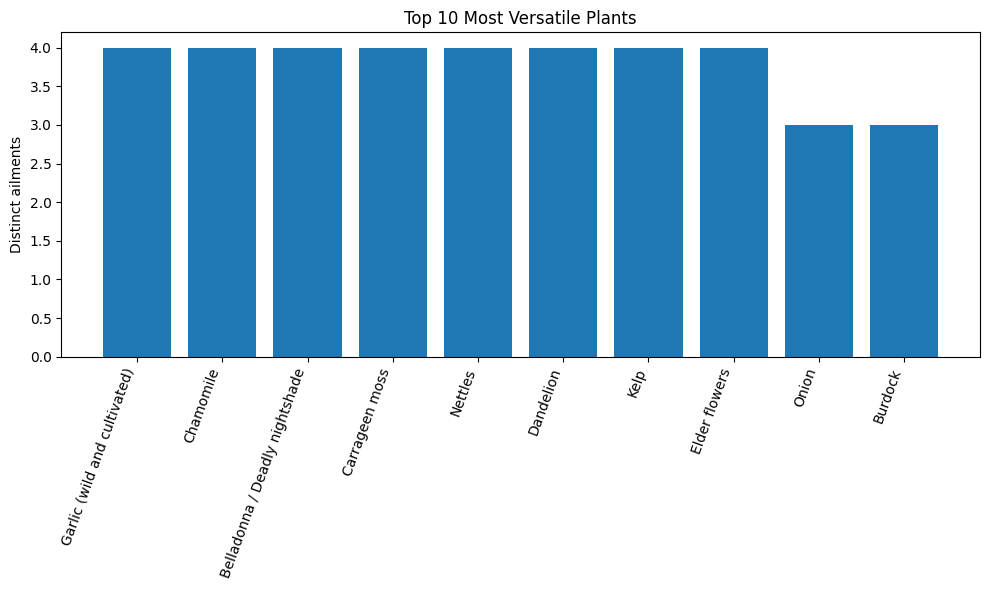

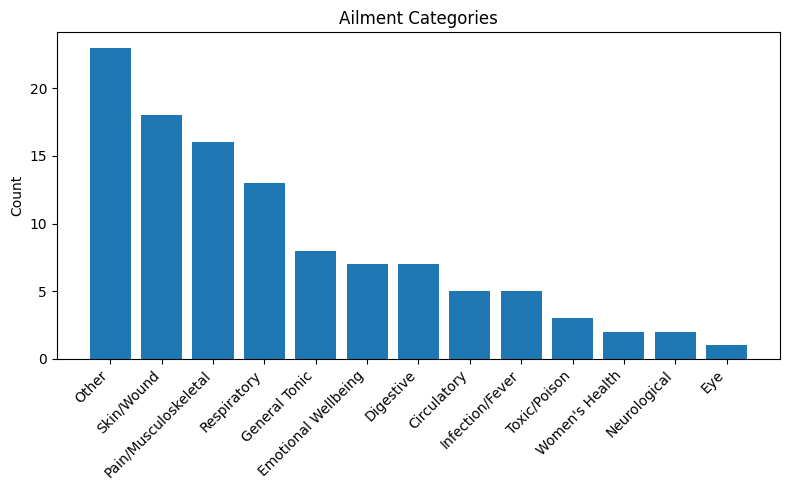

In [8]:

# STEP 6: Basic EDA charts
# ----------------------------------------------------------
os.makedirs("outputs/charts", exist_ok=True)

# Most versatile plants by raw ailment count
plant_usage_counts = (
    plant_ailments_df.groupby("plant_id")["ailment_name"]
    .nunique()
    .reset_index(name="ailment_count")
    .merge(plants_df[["plant_id", "plant_name"]], on="plant_id")
    .sort_values("ailment_count", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(plant_usage_counts.head(10)["plant_name"], plant_usage_counts.head(10)["ailment_count"])
plt.xticks(rotation=70, ha="right")
plt.title("Top 10 Most Versatile Plants")
plt.ylabel("Distinct ailments")
plt.tight_layout()
plt.show()

# Category distribution
category_counts = plant_ailments_df["category_name"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(category_counts.index, category_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Ailment Categories")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [11]:

# STEP 27: Load features extracted from Neo4j
# ----------------------------------------------------------
uploaded = files.upload()

feature_file = "plant_graph_features_V2.csv"
features_df = pd.read_csv(feature_file)

print(features_df.head())
print(features_df.shape)

Saving plant_graph_features_V2.csv to plant_graph_features_V2 (1).csv
               plant_id                      plant_name      irish_name  \
0    aloe_vera_l_burm_f                       Aloe vera             NaN   
1      arnica_montana_l                          Arnica             NaN   
2  borago_officinalis_l                      Bee borage  Borrairte gorm   
3   atropa_belladonna_l  Belladonna / Deadly nightshade    Miotóg buide   
4             rubus_spp                      Blackberry   Sceach / Dris   

          family  famine_food toxicity_class  ailment_count  category_count  \
0  Asphodelaceae        False            Low              1               1   
1     Asteraceae        False            Low              2               1   
2   Boraginaceae        False            Low              1               1   
3     Solanaceae        False           High              4               4   
4       Rosaceae        False            Low              1               1   

   s

In [12]:

# STEP 28: ML feature table preparation
# ----------------------------------------------------------
ml_df = features_df.copy()

# Simple mappings
tox_map = {"Low": 0, "Medium": 1, "High": 2}
ml_df["toxicity_numeric"] = ml_df["toxicity_class"].map(tox_map)

ml_df["famine_food"] = ml_df["famine_food"].astype(int)
ml_df["safe_multi_use"] = ml_df["safe_multi_use"].astype(int)

# One-hot encode selected categoricals
ml_df = pd.get_dummies(
    ml_df,
    columns=["family", "access_pattern"],
    drop_first=True
)

print(ml_df.head())

               plant_id                      plant_name      irish_name  \
0    aloe_vera_l_burm_f                       Aloe vera             NaN   
1      arnica_montana_l                          Arnica             NaN   
2  borago_officinalis_l                      Bee borage  Borrairte gorm   
3   atropa_belladonna_l  Belladonna / Deadly nightshade    Miotóg buide   
4             rubus_spp                      Blackberry   Sceach / Dris   

   famine_food toxicity_class  ailment_count  category_count  shop_count  \
0            0            Low              1               1           1   
1            0            Low              2               1           1   
2            0            Low              1               1           2   
3            0           High              4               4           1   
4            0            Low              1               1           2   

   location_count  degree_centrality  ...  family_Polygonaceae  \
0               1         

In [13]:

# STEP 29: Select features for K-Means
# ----------------------------------------------------------
cluster_features = [
    "ailment_count",
    "category_count",
    "shop_count",
    "location_count",
    "degree_centrality",
    "betweenness",
    "community_id",
    "toxicity_numeric",
    "famine_food",
    "safe_multi_use"
]

X_cluster = ml_df[cluster_features].fillna(0)

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

In [14]:

# STEP 30: K-Means clustering
# ----------------------------------------------------------
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
ml_df["k_cluster"] = kmeans.fit_predict(X_cluster_scaled)

print(ml_df[["plant_name", "k_cluster"]].head(15))
print("Silhouette score:", silhouette_score(X_cluster_scaled, ml_df["k_cluster"]))

                        plant_name  k_cluster
0                        Aloe vera          2
1                           Arnica          2
2                       Bee borage          3
3   Belladonna / Deadly nightshade          1
4                       Blackberry          3
5                          Bogbean          0
6                          Burdock          1
7                          Cabbage          0
8                   Carrageen moss          1
9                        Chamomile          1
10                        Charlock          2
11                          Cloves          2
12          Comfrey / 'Knit bones'          1
13                       Dandelion          1
14                            Dock          2
Silhouette score: 0.33930254675259347


In [15]:

# STEP 31: Cluster Interpretation
# ----------------------------------------------------------
cluster_summary = ml_df.groupby("k_cluster")[cluster_features].mean().round(2)
print(cluster_summary)

cluster_members = ml_df.groupby("k_cluster")["plant_name"].apply(list)
print(cluster_members)

           ailment_count  category_count  shop_count  location_count  \
k_cluster                                                              
0                   1.73            1.73         1.0             1.0   
1                   3.62            2.92         1.0             1.0   
2                   1.19            1.10         1.0             1.0   
3                   1.00            1.00         2.0             1.0   

           degree_centrality  betweenness  community_id  toxicity_numeric  \
k_cluster                                                                   
0                       2.00        69.08         58.33              0.00   
1                       4.00       291.57         69.85              0.23   
2                       1.24        21.92         84.29              0.24   
3                       1.00         0.00         53.50              0.00   

           famine_food  safe_multi_use  
k_cluster                               
0                 0.00

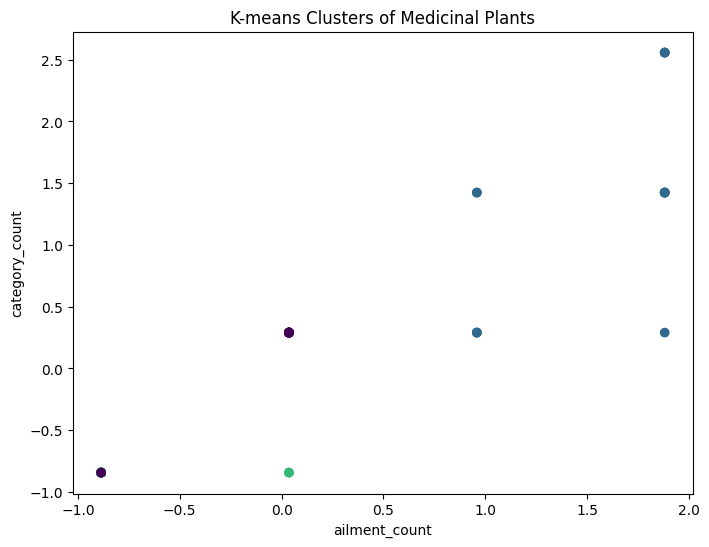

In [16]:

# STEP 32: Cluster Visualization
# ----------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(X_cluster_scaled[:, 0], X_cluster_scaled[:, 1], c=ml_df["k_cluster"])
plt.xlabel(cluster_features[0])
plt.ylabel(cluster_features[1])
plt.title("K-means Clusters of Medicinal Plants")
plt.show()

In [17]:

# STEP 33: LASSO Regression
# ----------------------------------------------------------
target = "ailment_count"

predictor_features = [
    col for col in ml_df.columns
    if col not in [
        "plant_id", "plant_name", "irish_name",
        "toxicity_class", target
    ]
]

X = ml_df[predictor_features].fillna(0)
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train_scaled, y_train)

y_pred = lasso.predict(X_test_scaled)

print("R2:", r2_score(y_test, y_pred))

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)


R2: 0.8819489665454631
RMSE: 0.4592984881346574


                 feature  coefficient
4      degree_centrality     0.470321
7         safe_multi_use     0.180813
1         category_count     0.115320
5            betweenness     0.083953
3         location_count     0.000000
0            famine_food    -0.000000
2             shop_count    -0.000000
6           community_id    -0.000000
8       toxicity_numeric    -0.000000
9      family_Araliaceae     0.000000
10  family_Asphodelaceae    -0.000000
11   family_Aspleniaceae    -0.000000
12     family_Asteraceae     0.000000
13   family_Boraginaceae    -0.000000
14   family_Brassicaceae     0.000000


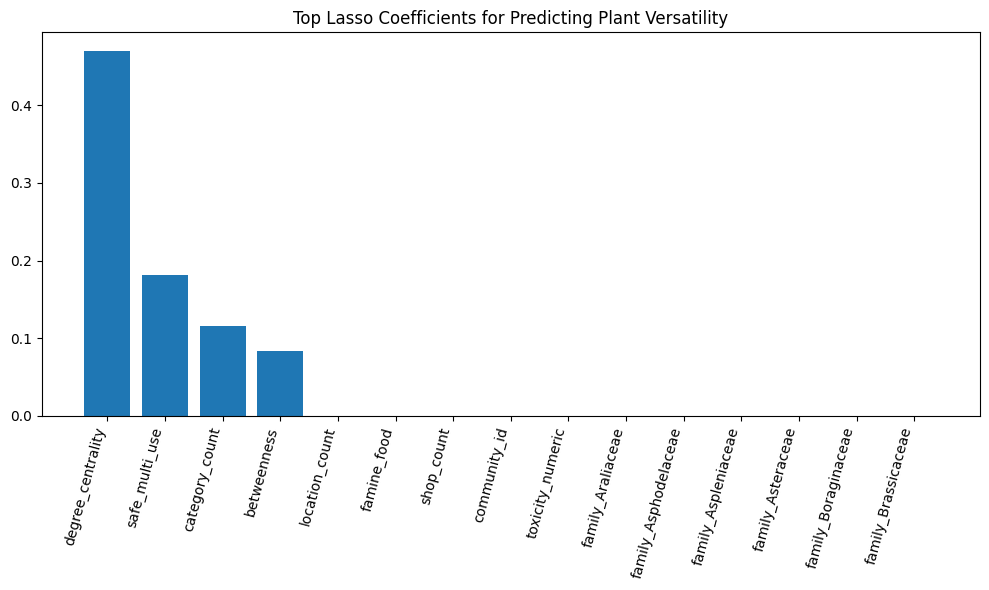

In [18]:

# STEP 34: LASSO Feature Importance
# ----------------------------------------------------------
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lasso.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df.head(15))

plt.figure(figsize=(10, 6))
plt.bar(coef_df.head(15)["feature"], coef_df.head(15)["coefficient"])
plt.xticks(rotation=75, ha="right")
plt.title("Top Lasso Coefficients for Predicting Plant Versatility")
plt.tight_layout()
plt.show()

In [19]:

# STEP 35: LOGISTIC Regression - safe multi use
# ----------------------------------------------------------
target_cls = "safe_multi_use"

predictor_features_cls = [
    col for col in ml_df.columns
    if col not in [
        "plant_id", "plant_name", "irish_name",
        "toxicity_class", target_cls
    ]
]

X_cls = ml_df[predictor_features_cls].fillna(0)
y_cls = ml_df[target_cls]

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42, stratify=y_cls
)

scaler_cls = StandardScaler()
X_train_scaled = scaler_cls.fit_transform(X_train)
X_test_scaled = scaler_cls.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_cls = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_cls))
print(classification_report(y_test, y_pred_cls))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         3

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



In [ ]:

# Completed Tasks:
# 1. Data preparation and normalization
# 2. Graph-ready CSV generation for Neo4j
# 3. Exploratory statistical analysis
# 4. Graph-derived feature preparation
# 5. K-means clustering
# 6. Lasso-based interpretive modelling
#
# Neo4j graph construction, graph algorithms, graph queries,
# and graph-learning outputs are provided separately
# in the accompanying Cypher code file.
